In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
from sklearn.datasets import fetch_california_housing

# Load the data -> Convert to df
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)

df['PRICE'] = california.target  # Add the target variable(Target variable -> what I want to predict)

print(f"Shape: {df.shape}") 
print(f"\nHead:\n{df.head()}")
print(f"\nFeature names:\n{california.feature_names}")

Shape: (20640, 9)

Head:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [10]:
# Basic dataset info
print("Dataset Info:")
print(df.info())  # Data types and missing values
print("\n" + "="*50) # Better for readability

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   PRICE       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


Statistical Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0

In [12]:
print("Missing values")
missing = df.isnull().sum()
print(missing)

# Summary 
if missing .sum() == 0:
    print("No missing values in the dataset.")
else:    
    print(f"Total missing values: {missing.sum()}")

Missing values
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
PRICE         0
dtype: int64
No missing values in the dataset.


House price statistics:
Mean price: 2.07
Median price: 1.80
Min price: 0.15
Max price: 5.00
Standard deviation: 1.15


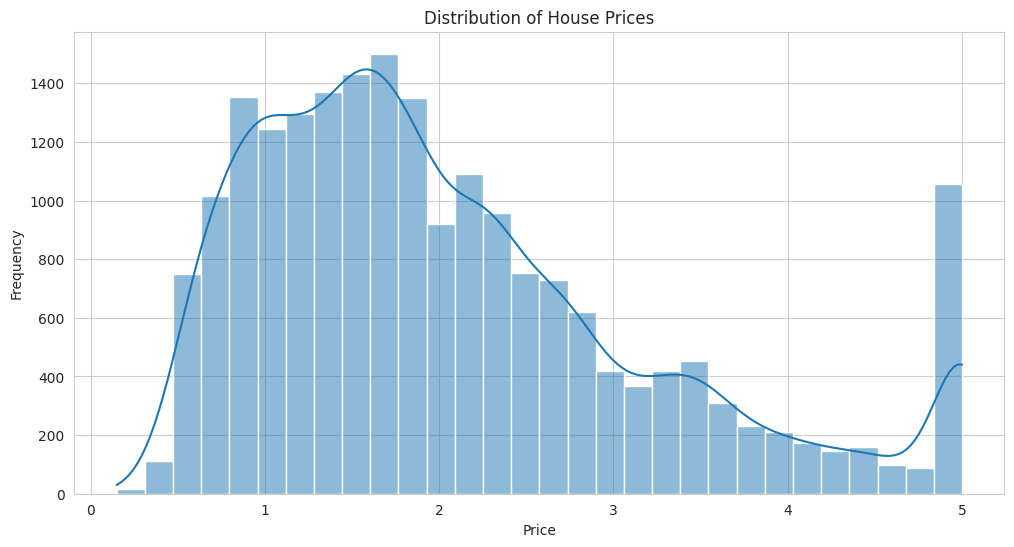

In [ ]:
prices = df['PRICE']

print("House price statistics:")
print(f"Mean price: {prices.mean():.2f}")
print(f"Median price: {prices.median():.2f}")
print(f"Min price: {prices.min():.2f}")
print(f"Max price: {prices.max():.2f}")
print(f"Standard deviation: {prices.std():.2f}")


# Visualize distribution 
sns.histplot(prices, bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Feature Descriptions:
MedInc: Median income in block
AveRooms: Average number of rooms per house
HouseAge: Median house age in block
Population: Population in block




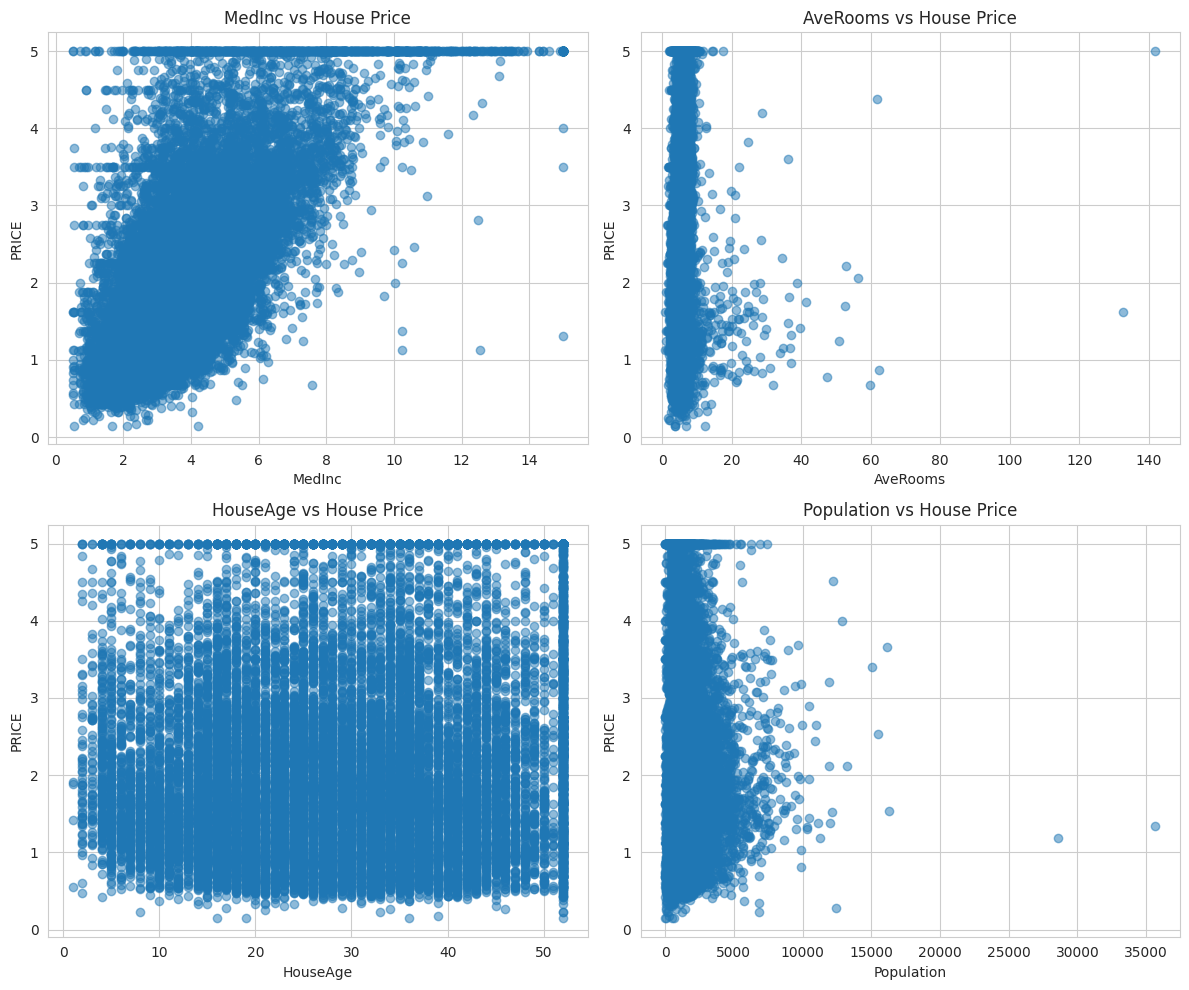

Correlation with Price:
MedInc: 0.688
AveRooms: 0.152
HouseAge: 0.106
Population: -0.025


In [17]:
# Look at a few key features
features_to_explore = ['MedInc', 'AveRooms', 'HouseAge', 'Population']

print("Feature Descriptions:")
print("MedInc: Median income in block")
print("AveRooms: Average number of rooms per house")
print("HouseAge: Median house age in block")
print("Population: Population in block")
print("\n" + "="*50 + "\n")

# Visualize relationships with price
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, feature in enumerate(features_to_explore):
    axes[idx].scatter(df[feature], df['PRICE'], alpha=0.5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('PRICE')
    axes[idx].set_title(f'{feature} vs House Price')

plt.tight_layout()
plt.show()

# Print correlation with price
print("Correlation with Price:")
for feature in features_to_explore:
    corr = df[feature].corr(df['PRICE'])
    print(f"{feature}: {corr:.3f}")

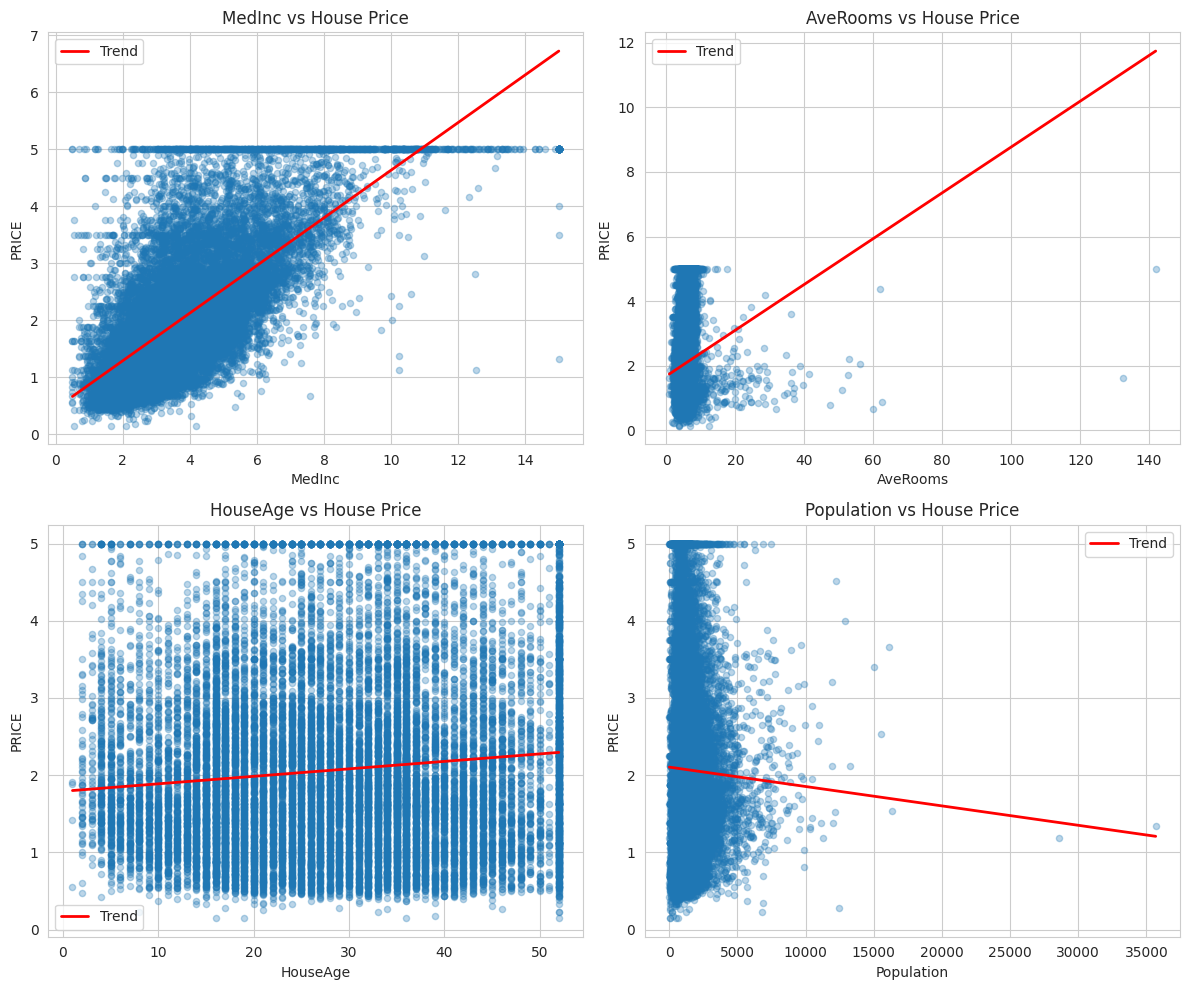

Correlation Strength:
MedInc: 0.688
AveRooms: 0.152
HouseAge: 0.106
Population: -0.025


In [18]:
# Better visualization with trend line
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

features_to_explore = ['MedInc', 'AveRooms', 'HouseAge', 'Population']

for idx, feature in enumerate(features_to_explore):
    # Scatter plot
    axes[idx].scatter(df[feature], df['PRICE'], alpha=0.3, s=20)
    
    # Add trend line to see the relationship better
    z = np.polyfit(df[feature], df['PRICE'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r-", linewidth=2, label='Trend')
    
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('PRICE')
    axes[idx].set_title(f'{feature} vs House Price')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Print correlations for clarity
print("Correlation Strength:")
for feature in features_to_explore:
    corr = df[feature].corr(df['PRICE'])
    print(f"{feature}: {corr:.3f}")